In [ ]:
!pip install lifelines

In [ ]:
import copy
import os
import random
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from scipy.stats import pearsonr

RNG_SEED = 42

In [ ]:
def print_env_versions() -> None:
    """Print versions of Python and key libraries for reproducibility."""
    print("Environment versions")
    print("--------------------")
    print(f"Python      : {sys.version.split()[0]}")
    print(f"NumPy       : {np.__version__}")
    print(f"Pandas      : {pd.__version__}")
    print(f"Matplotlib  : {plt.matplotlib.__version__}")
    print(f"SciPy       : {pearsonr.__module__.split('.')[0]} (via scipy)")
    print(f"  - SciPy   : {scipy.__version__}")
    print(f"NetworkX    : {nx.__version__}")
    print(f"Lifelines   : {CoxPHFitter.__module__.split('.')[0]}")
    import lifelines
    print(f"  - lifelines: {lifelines.__version__}")

In [ ]:
print_env_versions()

Environment versions
--------------------
Python      : 3.12.12
NumPy       : 2.0.2
Pandas      : 2.2.2
Matplotlib  : 3.10.0
SciPy       : scipy (via scipy)
  - SciPy   : 1.16.3
NetworkX    : 3.6
Lifelines   : lifelines
  - lifelines: 0.30.0


In [ ]:
def seed_all(seed: int = RNG_SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
IRSD_WEIGHTS = {
    1: 0.2136,
    2: 0.1622,
    3: 0.2393,
    4: 0.1678,
    5: 0.2171,
}

IRSD_QUINTILES = np.array([1, 2, 3, 4, 5])
IRSD_PROBS     = np.array([IRSD_WEIGHTS[q] for q in IRSD_QUINTILES])

def sample_irsd_quintile(n, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    return rng.choice(IRSD_QUINTILES, size=n, p=IRSD_PROBS)

#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
AGE_MEAN = 49.80
AGE_SD   = 12.39
AGE_MIN  = 18
AGE_MAX  = 90

def sample_age(n, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    age = rng.normal(loc=AGE_MEAN, scale=AGE_SD, size=n)
    return np.clip(age, AGE_MIN, AGE_MAX)

###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
SMOKING_STATES = np.array(["non", "current", "ex"])

SMOKING_PROB_MAP_IRSD = {
    1: {"non": 0.64,  "current": 0.16,  "ex": 0.20},
    2: {"non": 0.695, "current": 0.125, "ex": 0.18},
    3: {"non": 0.73,  "current": 0.10,  "ex": 0.17},
    4: {"non": 0.775, "current": 0.075, "ex": 0.15},
    5: {"non": 0.81,  "current": 0.05,  "ex": 0.14},
}

def sample_smoking_given_irsd(irsd_quintile, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    n = len(irsd_quintile)
    out = np.empty(n, dtype=object)
    for q in IRSD_QUINTILES:
        idx = np.where(irsd_quintile == q)[0]
        if len(idx) == 0:
            continue
        p = SMOKING_PROB_MAP_IRSD[q]
        probs = np.array([p["non"], p["current"], p["ex"]])
        out[idx] = rng.choice(SMOKING_STATES, size=len(idx), p=probs)
    return out

#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
BMI_MEAN = 28.29
BMI_SD   = 4.98
BMI_MIN  = 15.0
BMI_MAX  = 60.0
DELTA_BMI = 0.6
Q_CENTER  = 3

#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
def compute_bmi_means_by_irsd():
    w = IRSD_WEIGHTS
    S = sum(w[q] * (Q_CENTER - q) for q in IRSD_QUINTILES)
    mu_center = BMI_MEAN - DELTA_BMI * S
    mu = {}
    for q in IRSD_QUINTILES:
        mu[q] = mu_center + DELTA_BMI * (Q_CENTER - q)
    return mu

BMI_MEANS_BY_IRSD = compute_bmi_means_by_irsd()

def sample_bmi_given_irsd(irsd_quintile, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    n = len(irsd_quintile)
    bmi = np.empty(n, dtype=float)
    for q in IRSD_QUINTILES:
        idx = np.where(irsd_quintile == q)[0]
        if len(idx) == 0:
            continue
        mean_q = BMI_MEANS_BY_IRSD[q]
        bmi[idx] = rng.normal(loc=mean_q, scale=BMI_SD, size=len(idx))
    return np.clip(bmi, BMI_MIN, BMI_MAX)

###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
BASE_DM_PREV   = 0.0553
OR10_AGE_DM    = 1.8
OR5_BMI_DM     = 1.7

BETA_AGE_DM = np.log(OR10_AGE_DM)
BETA_BMI_DM = np.log(OR5_BMI_DM) / 5.0

ALPHA_DM = np.log(BASE_DM_PREV / (1 - BASE_DM_PREV))

def sample_diabetes_given_age_bmi(age, bmi, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    age = np.asarray(age)
    bmi = np.asarray(bmi)

    age_scaled = (age - AGE_MEAN) / 10.0
    bmi_centered = (bmi - BMI_MEAN)

    lin = ALPHA_DM + BETA_AGE_DM * age_scaled + BETA_BMI_DM * bmi_centered
    p = logistic(lin)
    return rng.binomial(1, p, size=len(age))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
TARGET_CKD_PREV      = 0.0045
OR10_AGE_CKD         = 1.4
OR_DM_CKD            = 3.0
OR5_BMI_CKD          = 1.5
OR_EX_VS_NON_CKD     = 1.2
OR_CURR_VS_NON_CKD   = 1.4

BETA_AGE_CKD    = np.log(OR10_AGE_CKD) / 10.0
BETA_DM_CKD     = np.log(OR_DM_CKD)
BETA_BMI_CKD    = np.log(OR5_BMI_CKD) / 5.0
BETA_EX_CKD     = np.log(OR_EX_VS_NON_CKD)
BETA_CURR_CKD   = np.log(OR_CURR_VS_NON_CKD)

ALPHA_CKD = np.log(TARGET_CKD_PREV / (1 - TARGET_CKD_PREV))

def sample_ckd(age, bmi, diabetes, smoking_status, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)

    age = np.asarray(age)
    bmi = np.asarray(bmi)
    diabetes = np.asarray(diabetes)
    smoking_status = np.asarray(smoking_status)

    age_centered = age - AGE_MEAN
    bmi_centered = bmi - BMI_MEAN

    lin = ALPHA_CKD
    lin += BETA_AGE_CKD * age_centered
    lin += BETA_DM_CKD * diabetes
    lin += BETA_BMI_CKD * bmi_centered
    lin[smoking_status == "ex"]      += BETA_EX_CKD
    lin[smoking_status == "current"] += BETA_CURR_CKD

    p = logistic(lin)
    return rng.binomial(1, p, size=len(age))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
HBA1C_MEAN_NODM = 4.60
HBA1C_SD_NODM   = 0.60
HBA1C_MEAN_DM   = 7.10
HBA1C_SD_DM     = 1.20

def sample_hba1c(diabetes, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    diabetes = np.asarray(diabetes)

    mean = np.where(diabetes == 1, HBA1C_MEAN_DM, HBA1C_MEAN_NODM)
    sd   = np.where(diabetes == 1, HBA1C_SD_DM,   HBA1C_SD_NODM)
    return rng.normal(loc=mean, scale=sd, size=len(diabetes))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
EGFR_MEAN = 82.97
BETA_AGE_EGFR = -0.18  # per year (≈ -1.8 per 10 yrs)
EGFR_SD_RESID = 5.0
DELTA_EGFR_CKD = -31.0  # CKD=1 vs 0

def sample_egfr(age, ckd, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)
    age = np.asarray(age)
    ckd = np.asarray(ckd)
    mean = EGFR_MEAN + BETA_AGE_EGFR * (age - AGE_MEAN) + DELTA_EGFR_CKD * ckd
    return rng.normal(loc=mean, scale=EGFR_SD_RESID, size=len(age))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
SBP_MEAN_TARGET = 122.07
BETA_AGE_SBP    = 0.38
BETA_BMI_SBP    = 1.0
DELTA_SBP_EX      = 1.7
DELTA_SBP_CURRENT = 3.8
DELTA_SBP_DM      = 8.0
DELTA_SBP_CKD     = 12.0

SBP_RESID_SD = 14.0

def sample_sbp(age, bmi, diabetes, ckd, smoking_status, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)

    age = np.asarray(age)
    bmi = np.asarray(bmi)
    diabetes = np.asarray(diabetes)
    ckd = np.asarray(ckd)
    smoking_status = np.asarray(smoking_status)

    shift_smoke = np.zeros(len(age))
    shift_smoke[smoking_status == "ex"]      = DELTA_SBP_EX
    shift_smoke[smoking_status == "current"] = DELTA_SBP_CURRENT

    mean_sbp = (
        SBP_MEAN_TARGET
        + BETA_AGE_SBP * (age - AGE_MEAN)
        + BETA_BMI_SBP * (bmi - BMI_MEAN)
        + DELTA_SBP_DM * diabetes
        + DELTA_SBP_CKD * ckd
        + shift_smoke
    )
    return rng.normal(loc=mean_sbp, scale=SBP_RESID_SD, size=len(age))


###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
TARGET_AF_PREV      = 0.0057
OR10_AGE_AF         = 1.7
OR_CKD_AF           = 3.0
OR_EX_VS_NON_AF     = 1.1
OR_CURR_VS_NON_AF   = 1.3

BETA_AGE_AF   = np.log(OR10_AGE_AF) / 10.0
BETA_CKD_AF   = np.log(OR_CKD_AF)
BETA_EX_AF    = np.log(OR_EX_VS_NON_AF)
BETA_CURR_AF  = np.log(OR_CURR_VS_NON_AF)

ALPHA_AF = np.log(TARGET_AF_PREV / (1 - TARGET_AF_PREV))

def sample_af(age, ckd, smoking_status, rng=None):
    if rng is None:
        rng = np.random.default_rng(RNG_SEED)

    age = np.asarray(age)
    ckd = np.asarray(ckd)
    smoking_status = np.asarray(smoking_status)

    age_centered = age - AGE_MEAN

    lin = ALPHA_AF + BETA_AGE_AF * age_centered + BETA_CKD_AF * ckd
    lin[smoking_status == "ex"]      += BETA_EX_AF
    lin[smoking_status == "current"] += BETA_CURR_AF

    p = logistic(lin)
    return rng.binomial(1, p, size=len(age))


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def generate_synthetic_cohort_master(n, seed=RNG_SEED):
    rng = np.random.default_rng(seed)

    irsd = sample_irsd_quintile(n, rng=rng)
    age  = sample_age(n, rng=rng)

    smoking = sample_smoking_given_irsd(irsd, rng=rng)
    bmi     = sample_bmi_given_irsd(irsd, rng=rng)

    diabetes = sample_diabetes_given_age_bmi(age, bmi, rng=rng)
    ckd      = sample_ckd(age, bmi, diabetes, smoking, rng=rng)

    hba1c = sample_hba1c(diabetes, rng=rng)
    egfr  = sample_egfr(age, ckd, rng=rng)

    sbp = sample_sbp(age, bmi, diabetes, ckd, smoking, rng=rng)
    af  = sample_af(age, ckd, smoking, rng=rng)

    return pd.DataFrame({
        "IRSD_quintile": irsd,
        "Age": age,
        "smoking_status": smoking,
        "BMI": bmi,
        "diabetes": diabetes,
        "CKD": ckd,
        "HbA1c": hba1c,
        "eGFR": egfr,
        "SBP": sbp,
        "AF": af,
    })

In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def summarise_master_cohort(df):
    df = df.copy()

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    if "smoking_ord" not in df.columns:
        smoking_map = {"non": 0, "ex": 1, "current": 2}
        df["smoking_ord"] = df["smoking_status"].map(smoking_map)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    irsd_levels, irsd_counts = np.unique(df["IRSD_quintile"], return_counts=True)
    irsd_total = irsd_counts.sum()
    irsd_pct = {int(lvl): round(ct / irsd_total * 100, 2)
                for lvl, ct in zip(irsd_levels, irsd_counts)}

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    age_mean = round(df["Age"].mean(), 2)
    age_sd   = round(df["Age"].std(), 2)
    age_med  = round(df["Age"].median(), 2)
    age_q1   = round(df["Age"].quantile(0.25), 2)
    age_q3   = round(df["Age"].quantile(0.75), 2)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    levels, counts = np.unique(df["smoking_status"], return_counts=True)
    total = counts.sum()
    smoking_pct = {lvl: round(ct / total * 100, 2)
                   for lvl, ct in zip(levels, counts)}

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    bmi_mean   = round(df["BMI"].mean(), 2)
    bmi_sd     = round(df["BMI"].std(), 2)

    sbp_mean   = round(df["SBP"].mean(), 2)
    sbp_sd     = round(df["SBP"].std(), 2)

    egfr_mean  = round(df["eGFR"].mean(), 2)
    egfr_sd    = round(df["eGFR"].std(), 2)

    hba1c_mean = round(df["HbA1c"].mean(), 2)
    hba1c_sd   = round(df["HbA1c"].std(), 2)

    diab_pct   = round(df["diabetes"].mean() * 100, 2)
    ckd_pct    = round(df["CKD"].mean() * 100, 3)
    af_pct     = round(df["AF"].mean() * 100, 3)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    by_irsd = (
        df.groupby("IRSD_quintile")
          .agg(
              n         = ("diabetes", "size"),
              diab_pct  = ("diabetes", lambda x: 100 * x.mean()),
              CKD_pct   = ("CKD", lambda x: 100 * x.mean()),
              AF_pct    = ("AF", lambda x: 100 * x.mean()),
              SBP_mean  = ("SBP", "mean"),
              SBP_sd    = ("SBP", "std"),
          )
          .sort_index()
    )

    by_irsd["diab_pct"] = by_irsd["diab_pct"].round(2)
    by_irsd["CKD_pct"]  = by_irsd["CKD_pct"].round(3)
    by_irsd["AF_pct"]   = by_irsd["AF_pct"].round(3)
    by_irsd["SBP_mean"] = by_irsd["SBP_mean"].round(2)
    by_irsd["SBP_sd"]   = by_irsd["SBP_sd"].round(2)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    by_dm = (
        df.groupby("diabetes")
          .agg(
              n         = ("CKD", "size"),
              CKD_pct   = ("CKD", lambda x: 100 * x.mean()),
              AF_pct    = ("AF", lambda x: 100 * x.mean()),
              HbA1c_mean= ("HbA1c", "mean"),
              HbA1c_sd  = ("HbA1c", "std"),
              eGFR_mean = ("eGFR", "mean"),
              eGFR_sd   = ("eGFR", "std"),
              SBP_mean  = ("SBP", "mean"),
              SBP_sd    = ("SBP", "std"),
          )
          .sort_index()
    )

    for col in ["CKD_pct", "AF_pct"]:
        by_dm[col] = by_dm[col].round(3)
    for col in ["HbA1c_mean", "HbA1c_sd", "eGFR_mean", "eGFR_sd",
                "SBP_mean", "SBP_sd"]:
        by_dm[col] = by_dm[col].round(2)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    vars_list = [
        "IRSD_quintile", "Age", "smoking_ord",
        "BMI", "diabetes", "CKD",
        "HbA1c", "eGFR", "SBP", "AF"
    ]
    corr_mat = df[vars_list].corr().round(3)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    print("====================================================")
    print("      HARMONISED MASTER SYNTHETIC COHORT SUMMARY")
    print("====================================================")

    print("\nIRSD Quintile Distribution (%):")
    for q in sorted(irsd_pct.keys()):
        print(f"  Q{q}: {irsd_pct[q]:>6.2f}%")

    print("\nAge:")
    print(f"  Mean (SD)     : {age_mean} ({age_sd})")
    print(f"  Median [IQR]  : {age_med} [{age_q1}, {age_q3}]")

    print("\nSmoking Status Distribution (%):")
    for lvl in sorted(smoking_pct.keys()):
        print(f"  {lvl:<8}: {smoking_pct[lvl]:>6.2f}%")

    print("\nOverall Prevalences:")
    print(f"  Diabetes : {diab_pct:>7.2f}%")
    print(f"  CKD      : {ckd_pct:>7.3f}%")
    print(f"  AF       : {af_pct:>7.3f}%")

    print("\nOverall Continuous Variables:")
    print(f"  BMI   Mean (SD): {bmi_mean:>6.2f} ({bmi_sd:>6.2f})")
    print(f"  SBP   Mean (SD): {sbp_mean:>6.2f} ({sbp_sd:>6.2f})")
    print(f"  eGFR  Mean (SD): {egfr_mean:>6.2f} ({egfr_sd:>6.2f})")
    print(f"  HbA1c Mean (SD): {hba1c_mean:>6.2f} ({hba1c_sd:>6.2f})")

    print("\nBy-IRSD Breakdown (n, Diabetes%, CKD%, AF%, SBP mean±SD):")
    for q in sorted(by_irsd.index):
        row = by_irsd.loc[q]
        print(
            f"  Q{int(q)} | n={int(row['n']):>7d} | "
            f"DM={row['diab_pct']:>6.2f}% | "
            f"CKD={row['CKD_pct']:>6.3f}% | "
            f"AF={row['AF_pct']:>6.3f}% | "
            f"SBP={row['SBP_mean']:>6.2f}±{row['SBP_sd']:>5.2f}"
        )

    print("\nBy-Diabetes Breakdown (0 = no DM, 1 = DM):")
    for dm in [0, 1]:
        if dm in by_dm.index:
            row = by_dm.loc[dm]
            print(
                f"  DM={dm} | n={int(row['n']):>7d} | "
                f"CKD={row['CKD_pct']:>6.3f}% | "
                f"AF={row['AF_pct']:>6.3f}% | "
                f"HbA1c={row['HbA1c_mean']:>5.2f}±{row['HbA1c_sd']:>4.2f} | "
                f"eGFR={row['eGFR_mean']:>6.2f}±{row['eGFR_sd']:>5.2f} | "
                f"SBP={row['SBP_mean']:>6.2f}±{row['SBP_sd']:>5.2f}"
            )

    print("\nPearson Correlation Matrix (key numeric vars):")
    print(corr_mat)

    print("====================================================")


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def pairplot_master(df):

    df = df.copy()

    if "smoking_ord" not in df.columns:
        smoking_map = {"non": 0, "ex": 1, "current": 2}
        df["smoking_ord"] = df["smoking_status"].map(smoking_map)

    vars_list = [
        "IRSD_quintile",
        "Age",
        "smoking_ord",
        "BMI",
        "diabetes",
        "CKD",
        "HbA1c",
        "eGFR",
        "SBP",
        "AF",
    ]
    k = len(vars_list)

    fig, axes = plt.subplots(k, k, figsize=(2 * k, 2 * k))

    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            xvar = vars_list[j]
            yvar = vars_list[i]

            if i == j:
                ax.hist(df[xvar], bins=20)
                ax.set_ylabel("")
                ax.set_xlabel("")

            elif i > j:
                ax.scatter(df[xvar], df[yvar], s=2)
                ax.set_ylabel("")
                ax.set_xlabel("")
            else:
                x = df[xvar]
                y = df[yvar]

                try:
                    r, _ = pearsonr(x, y)
                except Exception:
                    r = np.nan

                ax.text(
                    0.5, 0.5,
                    f"{r:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    transform=ax.transAxes,
                )
                ax.set_xticks([])
                ax.set_yticks([])

            if i < k - 1:
                ax.set_xticklabels([])
            if j > 0:
                ax.set_yticklabels([])

    for i in range(k):
        axes[i, 0].set_ylabel(vars_list[i], fontsize=10)
        axes[-1, i].set_xlabel(vars_list[i], fontsize=10, rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def plot_master_dag_simple():

    G = nx.DiGraph()

    edges = [
        ("IRSD", "smoking_status"),
        ("IRSD", "BMI"),

        ("Age", "diabetes"),
        ("BMI", "diabetes"),

        ("Age", "CKD"),
        ("diabetes", "CKD"),
        ("smoking_status", "CKD"),
        ("BMI", "CKD"),

        ("diabetes", "HbA1c"),

        ("Age", "eGFR"),
        ("CKD", "eGFR"),

        ("Age", "SBP"),
        ("smoking_status", "SBP"),
        ("BMI", "SBP"),
        ("diabetes", "SBP"),
        ("CKD", "SBP"),

        ("Age", "AF"),
        ("smoking_status", "AF"),
        ("CKD", "AF"),
    ]

    G.add_edges_from(edges)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    layers = {
        0: ["IRSD", "Age"],
        1: ["smoking_status", "BMI", "diabetes", "CKD"],
        2: ["HbA1c", "eGFR", "SBP", "AF"],
    }

    pos = {}
    for x, nodes in layers.items():
        if len(nodes) == 1:
            ys = [0.5]
        else:
            ys = list(np.linspace(0.1, 0.9, len(nodes)))
        for y, node in zip(ys, nodes):
            pos[node] = (x, y)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    plt.figure(figsize=(10, 6))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=3000,
        font_size=10,
        arrowsize=20,
        arrowstyle="-|>",
    )

    plt.title("Master Synthetic Data DAG")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def compute_lp_master_selected(df):
    beta = {}

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    beta["Age"] = np.log(1.07)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    beta["irsd_q1"] = np.log(0.95)
    beta["irsd_q2"] = np.log(1.03)
    beta["irsd_q3"] = np.log(1.04)
    beta["irsd_q4"] = np.log(0.96)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    beta["smk_current"] = np.log(1.68)
    beta["smk_ex"]      = np.log(1.35)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    beta["AF"]   = np.log(3.70)
    beta["CKD"]  = np.log(1.01)
    beta["DM"]   = np.log(5.04)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    beta["HbA1c"] = np.log(1.42)
    beta["BMI"]   = np.log(1.02)
    beta["eGFR"]  = np.log(0.99)
    beta["SBP"]   = np.log(1.01)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    age = df["Age"].astype(float)
    age_term = (age - 30.0)

    irsd = df["IRSD_quintile"]
    irsd_q1 = (irsd == 1).astype(float)
    irsd_q2 = (irsd == 2).astype(float)
    irsd_q3 = (irsd == 3).astype(float)
    irsd_q4 = (irsd == 4).astype(float)

    smk = df["smoking_status"]
    smk_current = (smk == "current").astype(float)
    smk_ex      = (smk == "ex").astype(float)

    AF   = df["AF"].astype(float)
    CKD  = df["CKD"].astype(float)
    DM   = df["diabetes"].astype(float)

    HbA1c = df["HbA1c"].astype(float)
    BMI   = df["BMI"].astype(float)
    eGFR  = df["eGFR"].astype(float)
    SBP   = df["SBP"].astype(float)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    eta = np.zeros(len(df), dtype=float)

    eta += beta["Age"] * age_term

    eta += beta["irsd_q1"] * irsd_q1
    eta += beta["irsd_q2"] * irsd_q2
    eta += beta["irsd_q3"] * irsd_q3
    eta += beta["irsd_q4"] * irsd_q4

    eta += beta["smk_current"] * smk_current
    eta += beta["smk_ex"]      * smk_ex

    eta += beta["AF"]  * AF
    eta += beta["CKD"] * CKD
    eta += beta["DM"]  * DM

    eta += beta["HbA1c"] * HbA1c
    eta += beta["BMI"]   * BMI
    eta += beta["eGFR"]  * eGFR
    eta += beta["SBP"]   * SBP

    return eta


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def simulate_cvd_outcome_master(df,
                                baseline_hazard,
                                censor_mean=4.91,
                                censor_sd=0.54,
                                rng=None):

    if rng is None:
        rng = np.random.default_rng(RNG_SEED)

    eta = compute_lp_master_selected(df)
    lam = baseline_hazard * np.exp(eta)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    u = rng.uniform(size=len(df))
    t_event = -np.log(u) / lam

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    t_cens = rng.normal(loc=censor_mean, scale=censor_sd, size=len(df))
    t_cens = np.clip(t_cens, 0.5, 10.0)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    time = np.minimum(t_event, t_cens)
    event = (t_event <= t_cens).astype(int)

    return event, time


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
def calibrate_baseline_hazard(df,
                              target_event_rate=0.0395,
                              censor_mean=4.91,
                              censor_sd=0.54,
                              tol=1e-4,
                              max_iter=50,
                              seed=123):

    rng = np.random.default_rng(seed)

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    eta = compute_lp_master_selected(df)
    n = len(df)
    u = rng.uniform(size=n)
    t_cens = rng.normal(loc=censor_mean, scale=censor_sd, size=n)
    t_cens = np.clip(t_cens, 0.5, 10.0)

    def event_rate_for_h0(h0):
        lam = h0 * np.exp(eta)
        t_event = -np.log(u) / lam
        event = (t_event <= t_cens).astype(int)
        return event.mean()

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    h_low, h_high = 1e-5, 5e-3

    #>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>#>>===>>>
    while event_rate_for_h0(h_high) < target_event_rate and h_high < 1:
        h_high *= 2

    for _ in range(max_iter):
        h_mid = 0.5 * (h_low + h_high)
        er = event_rate_for_h0(h_mid)
        if abs(er - target_event_rate) < tol:
            return h_mid
        if er < target_event_rate:
            h_low = h_mid
        else:
            h_high = h_mid

    return h_mid


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
n = 50_000
df0 = generate_synthetic_cohort_master(n, seed=42)

h0 = calibrate_baseline_hazard(
    df0,
    target_event_rate=0.0395,
    censor_mean=4.91,
    censor_sd=0.54,
)

print("Calibrated baseline hazard h0 ≈", h0)

rng = np.random.default_rng(2025)
event, time = simulate_cvd_outcome_master(
    df0,
    baseline_hazard=h0,
    censor_mean=4.91,
    censor_sd=0.54,
    rng=rng
)

df0["cvd_event"] = event
df0["cvd_time"]  = time

print("Observed event rate:", df0["cvd_event"].mean())
print("Mean follow-up time:", df0["cvd_time"].mean())


Calibrated baseline hazard h0 ≈ 4.38067626953125e-05
Observed event rate: 0.04018
Mean follow-up time: 4.795509638164318


In [ ]:
df0

,IRSD_quintile,Age,smoking_status,BMI,diabetes,CKD,HbA1c,eGFR,SBP,AF,cvd_event,cvd_time
0,4,50.395265,non,28.166346,0,0,4.317890,83.077560,118.668194,0,1,2.963423
1,3,39.226761,ex,16.825992,0,0,4.700951,81.488401,123.719732,0,0,4.407252
2,5,55.489004,non,23.523419,0,0,3.669685,86.779230,126.650517,0,0,4.490739
3,4,51.910529,non,31.981932,0,0,4.486977,94.704093,113.889670,0,0,4.888965
4,1,47.091570,ex,25.351159,0,0,4.315440,86.336256,125.912615,0,0,4.490326
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,71.010364,ex,29.624177,0,0,4.129969,81.458799,138.610531,0,0,5.155653
49996,3,45.876439,current,40.064313,0,0,4.463158,83.469956,146.908577,0,0,4.762595
49997,5,63.104057,non,27.452017,0,0,5.236286,81.756055,124.015135,0,0,5.054845
49998,3,37.623413,non,26.810036,0,0,5.963833,93.174396,124.650934,0,0,4.499002


In [ ]:
seed_all()
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
###===######===######===######===######===######===######===######===###
# ----------------------------------------------------
# ----------------------------------------------------
df = df0.copy()

df["Age_c"] = df["Age"] - 30.0

irsd_dummies = pd.get_dummies(
    df["IRSD_quintile"],
    prefix="irsd",
    drop_first=False
)
if "irsd_5" in irsd_dummies.columns:
    irsd_dummies = irsd_dummies.drop(columns=["irsd_5"])

smoke_dummies = pd.get_dummies(
    df["smoking_status"],
    prefix="smoke",
    drop_first=False
)
if "smoke_non" in smoke_dummies.columns:
    smoke_dummies = smoke_dummies.drop(columns=["smoke_non"])

for col in ["AF", "CKD", "diabetes"]:
    df[col] = df[col].astype(int)

# ----------------------------------------------------
# ----------------------------------------------------
X = pd.concat(
    [
        df[["Age_c", "AF", "CKD", "diabetes",
            "HbA1c", "BMI", "eGFR", "SBP"]],
        smoke_dummies,
        irsd_dummies,
    ],
    axis=1
)

# ----------------------------------------------------
# ----------------------------------------------------
events = df["cvd_event"].astype(bool)

cols_to_drop = []
for col in X.columns:
    v_all      = X[col].var()
    v_event    = X.loc[events, col].var() if events.sum() > 0 else 0.0
    v_nonevent = X.loc[~events, col].var() if (~events).sum() > 0 else 0.0

    if (v_all < 1e-6) or (v_event < 1e-6) or (v_nonevent < 1e-6):
        cols_to_drop.append(col)

print("Dropping near-constant columns:", cols_to_drop)

X_reduced = X.drop(columns=cols_to_drop)

# ----------------------------------------------------
# ----------------------------------------------------
cox_df = pd.concat(
    [
        df[["cvd_time", "cvd_event"]],
        X_reduced,
    ],
    axis=1
)

# ----------------------------------------------------
# ----------------------------------------------------
cph = CoxPHFitter(penalizer=0.05)   # you can try 0.01–0.1, value judgement

cph.fit(
    cox_df,
    duration_col="cvd_time",
    event_col="cvd_event",
    show_progress=True,
)

cph.print_summary()

# ----------------------------------------------------
# ----------------------------------------------------
hr_table = cph.summary[[
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]].rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower_95",
    "exp(coef) upper 95%": "HR_upper_95",
    "p": "p_value",
})

print("\nHazard ratios (baseline: non-smoker, IRSD 5):")
print(np.round(hr_table, 2))


Dropping near-constant columns: []
Iteration 1: norm_delta = 1.06e+00, step_size = 0.9500, log_lik = -21528.74784, newton_decrement = 3.28e+03, seconds_since_start = 0.5
Iteration 2: norm_delta = 6.65e-01, step_size = 0.9500, log_lik = -20689.30710, newton_decrement = 1.81e+03, seconds_since_start = 1.1
Iteration 3: norm_delta = 2.41e-01, step_size = 0.9500, log_lik = -19608.29456, newton_decrement = 2.89e+02, seconds_since_start = 1.7
Iteration 4: norm_delta = 2.53e-02, step_size = 1.0000, log_lik = -19348.22851, newton_decrement = 4.74e+00, seconds_since_start = 2.5
Iteration 5: norm_delta = 2.19e-04, step_size = 1.0000, log_lik = -19343.47941, newton_decrement = 1.34e-04, seconds_since_start = 3.4
Iteration 6: norm_delta = 1.16e-08, step_size = 1.0000, log_lik = -19343.47927, newton_decrement = 7.78e-13, seconds_since_start = 4.5
Convergence success after 6 iterations.


<lifelines.CoxPHFitter: fitted with 50000 total observations, 47991 right-censored observations>
             duration col = 'cvd_time'
                event col = 'cvd_event'
                penalizer = 0.05
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 50000
number of events observed = 2009
   partial log-likelihood = -19343.48
         time fit was run = 2025-12-03 22:38:30 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
Age_c          0.03      1.03      0.00            0.03            0.03                1.03                1.03
AF             1.06      2.90      0.13            0.81            1.32                2.24                3.75
CKD           -0.03      0.97      0.13           -0.28            0.23                0.75                1.26
diabetes       1.42      4.15      0.05            1.33            1.52                3.77                4.57
HbA1c          0.32      1.37      0.01            0.29            0.34                1.33                1.41
BMI            0.01      1.01      0.00            0.01            0.02                1.01                1.02
eGFR          -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99
SBP            0.01      1.01      0.00            0.01            0.01                1.01                1.01
smoke_current  0.17      1.18      0.05            0.07            0.26                1.08                1.30
smoke_ex       0.16      1.17      0.04            0.08            0.23                1.08                1.26
irsd_1        -0.00      1.00      0.04           -0.08            0.07                0.93                1.07
irsd_2         0.04      1.04      0.04           -0.04            0.12                0.96                1.13
irsd_3         0.05      1.05      0.04           -0.02            0.12                0.98                1.12
irsd_4        -0.01      0.99      0.04           -0.09            0.07                0.91                1.07

               cmp to     z      p  -log2(p)
covariate                                   
Age_c            0.00 23.66 <0.005    408.56
AF               0.00  8.09 <0.005     50.55
CKD              0.00 -0.20   0.84      0.24
diabetes         0.00 28.90 <0.005    607.69
HbA1c            0.00 22.02 <0.005    354.56
BMI              0.00  3.88 <0.005     13.25
eGFR             0.00 -7.33 <0.005     42.01
SBP              0.00 10.27 <0.005     79.80
smoke_current    0.00  3.47 <0.005     10.92
smoke_ex         0.00  3.99 <0.005     13.86
irsd_1           0.00 -0.10   0.92      0.12
irsd_2           0.00  0.92   0.36      1.47
irsd_3           0.00  1.30   0.19      2.36
irsd_4           0.00 -0.23   0.82      0.29
---
Concordance = 0.87
Partial AIC = 38714.96
log-likelihood ratio test = 4370.54 on 14 df
-log2(p) of ll-ratio test = inf


Hazard ratios (baseline: non-smoker, IRSD 5):
                 HR  HR_lower_95  HR_upper_95  p_value
covariate                                             
Age_c          1.03         1.03         1.03     0.00
AF             2.90         2.24         3.75     0.00
CKD            0.97         0.75         1.26     0.84
diabetes       4.15         3.77         4.57     0.00
HbA1c          1.37         1.33         1.41     0.00
BMI            1.01         1.01         1.02     0.00
eGFR           0.98         0.98         0.99     0.00
SBP            1.01         1.01         1.01     0.00
smoke_current  1.18         1.08         1.30     0.00
smoke_ex       1.17         1.08         1.26     0.00
irsd_1         1.00         0.93         1.07     0.92
irsd_2         1.04         0.96         1.13     0.36
irsd_3         1.05         0.98         1.12     0.19
irsd_4         0.99         0.91         1.07     0.82


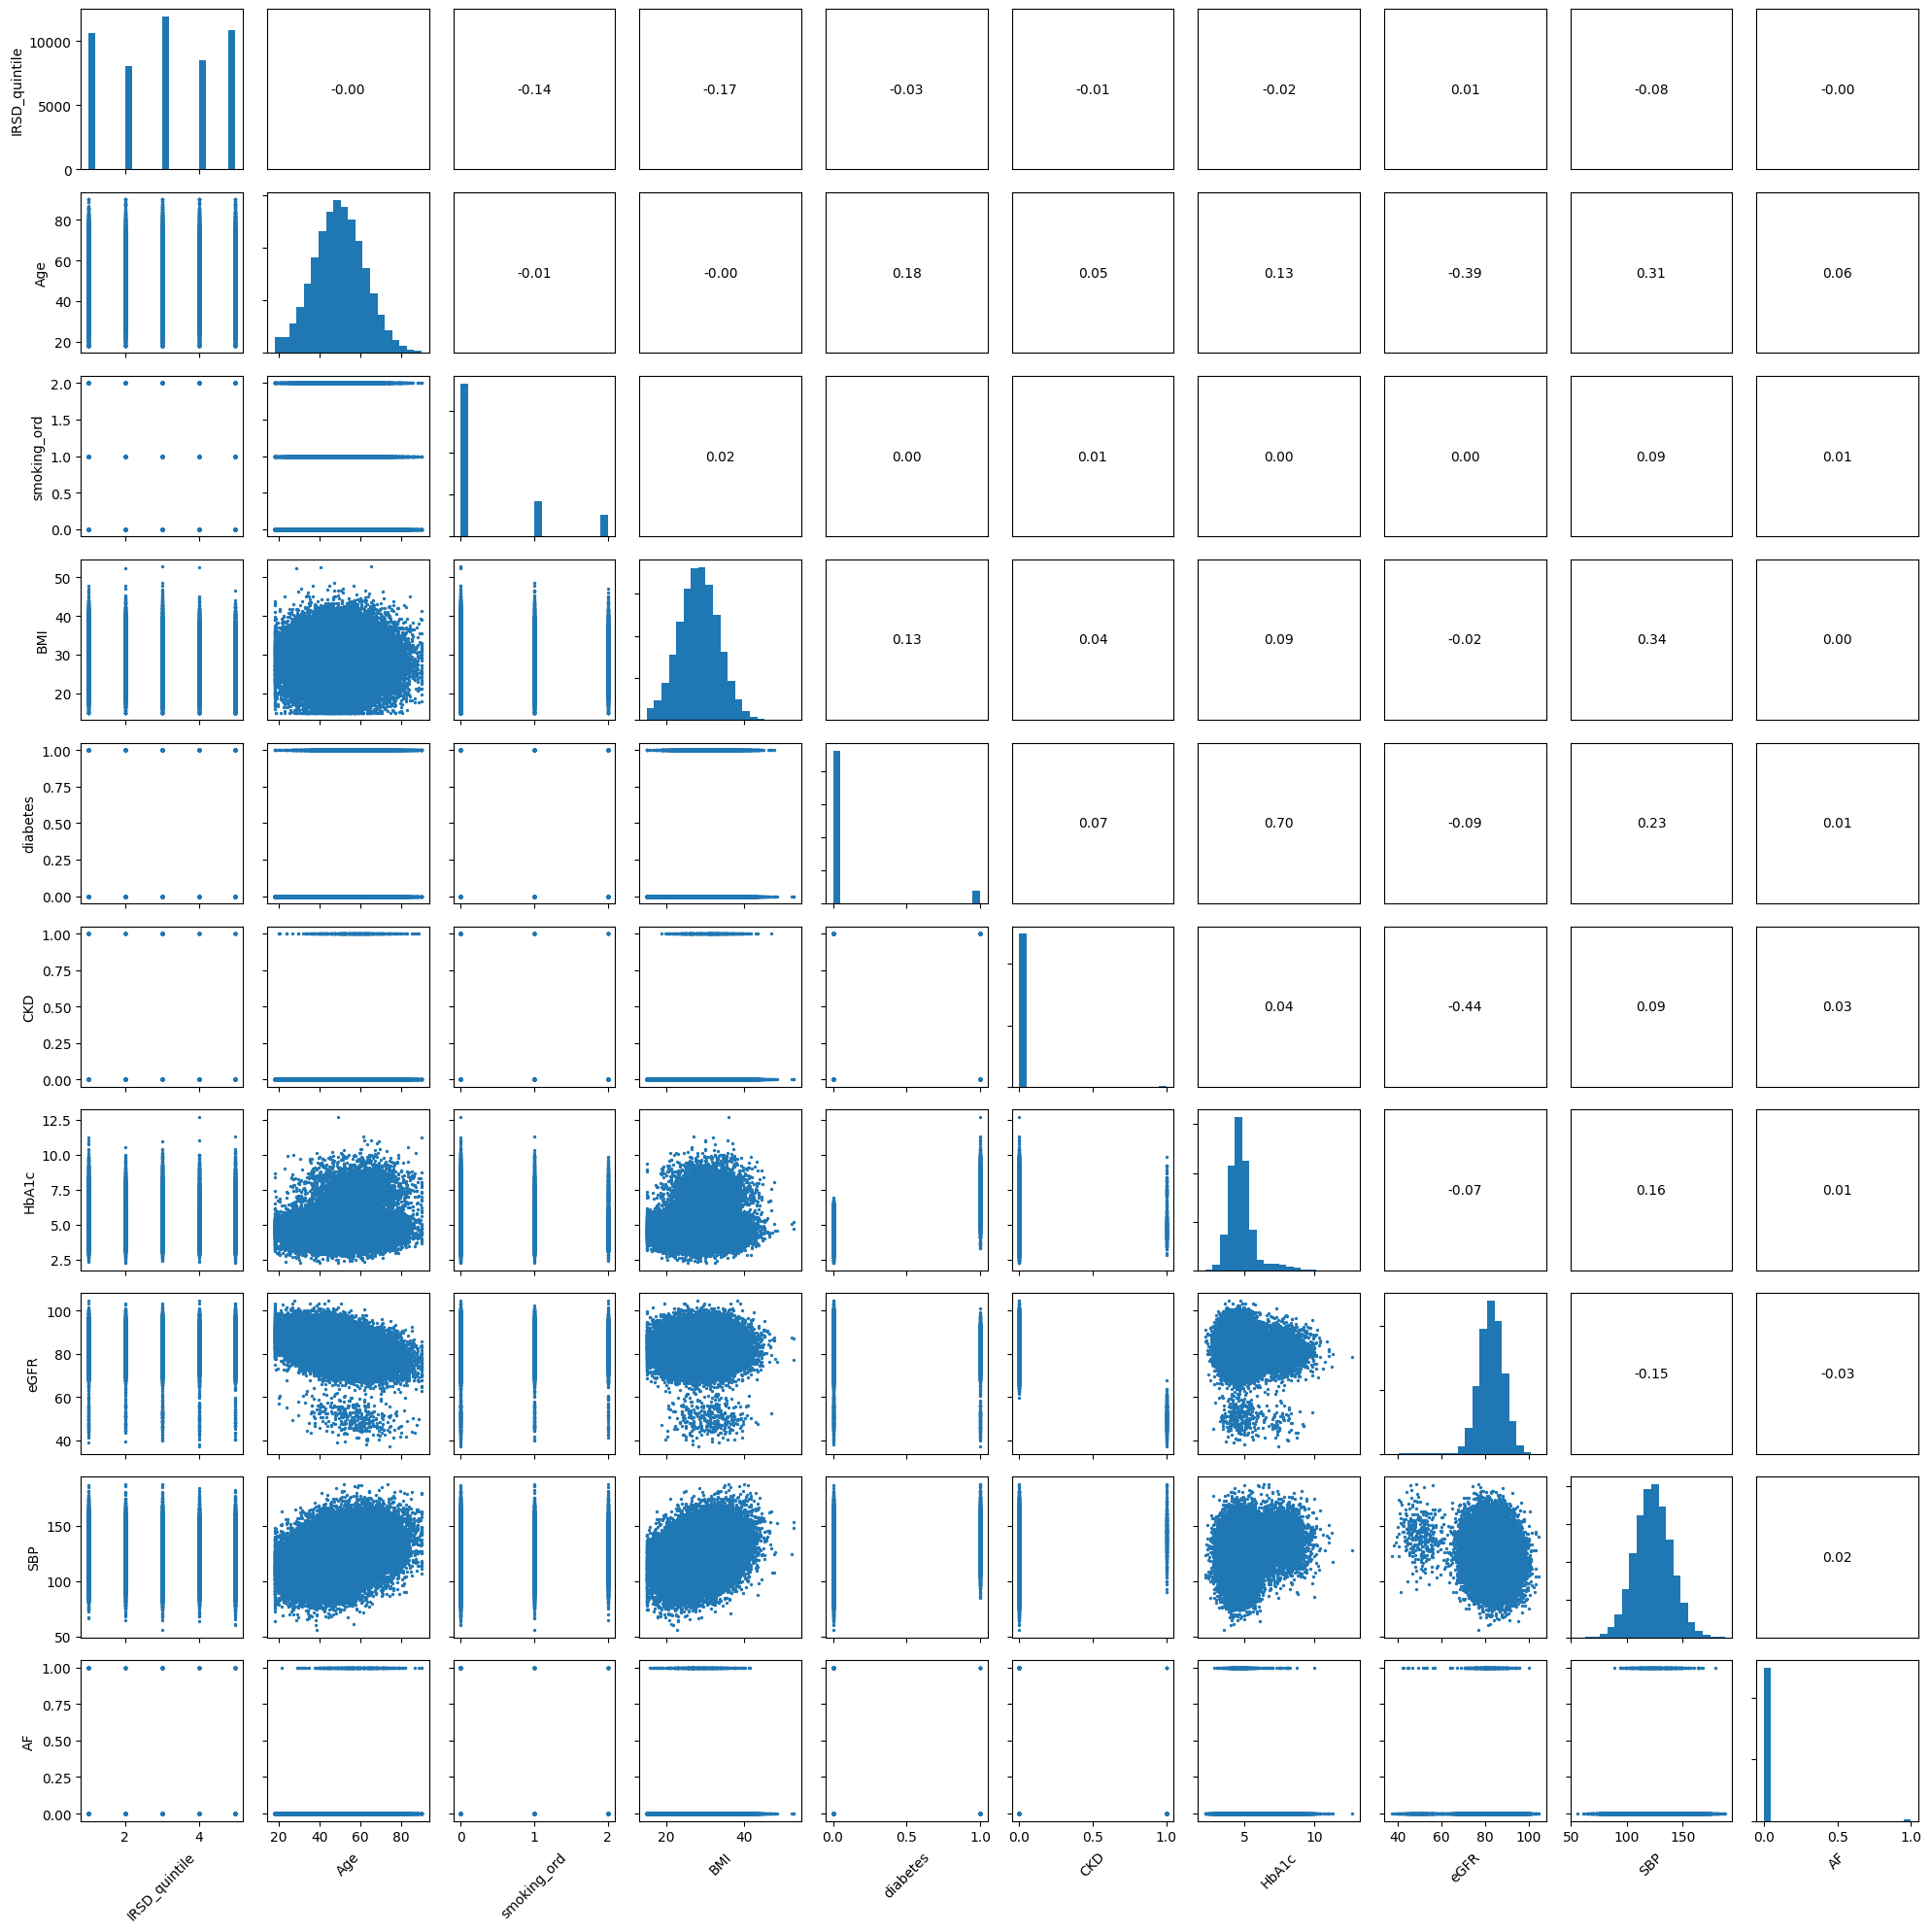

In [ ]:
pairplot_master(df0)

/tmp/ipython-input-3712264304.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


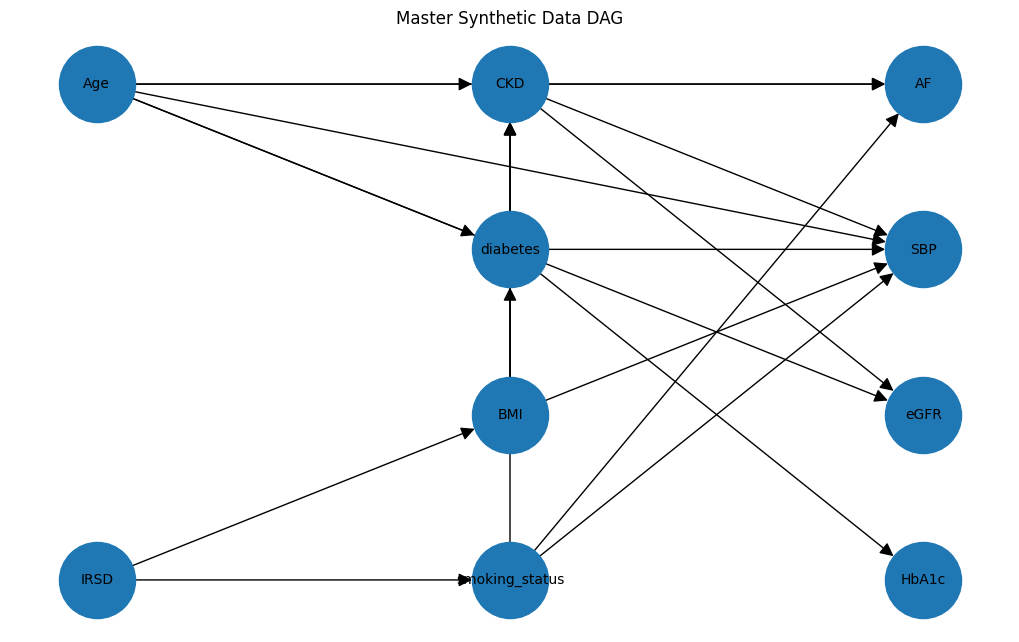

In [ ]:
plot_master_dag_simple()